In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

# Import data
file = '/content/drive/MyDrive/athlete_events.csv'
df = pd.read_csv(file)

print(df.shape)


(271116, 15)


In [2]:
def delete_df(df):
  del df
  gc.collect()

def choose_year(year: int, df: pd.DataFrame):
  try:
    if year not in df['Year'].unique():
      raise ValueError
    return df[df['Year'] == year].reset_index(drop=True)
  except:
    print('Invalid Year')

# **SCRIPT 1 - BASIC QUERIES**


# *1.1 - NUMBER OF ATHLETES PER SUMMER GAME*

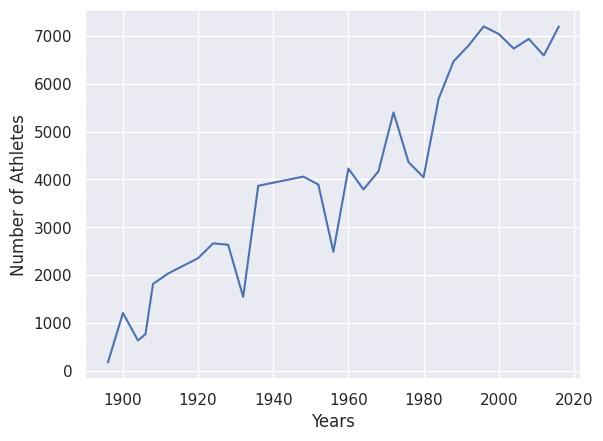

In [3]:
summer_games = (df[df['Games'].str.contains('Summer')]
                .drop_duplicates(['ID'])
                .groupby(['Year'])
                .size()
                .reset_index(name='Athletes')
                .sort_values('Year')

)

sns.set(style='darkgrid')
ax = sns.lineplot(data=summer_games, x='Year', y='Athletes')
ax.set(xlabel='Years', ylabel='Number of Athletes')
plt.show()

delete_df(summer_games)

# *1.2 - NUMBER OF MEDALS PER GAME*

   Year  Medal_Count
0  1896          143
1  1900          593
2  1904          486
3  1906          458
4  1908          831
5  1912          941
6  1920         1308
7  1924          832
8  1928          734
9  1932          647
Index(['Year', 'Medal_Count'], dtype='object')


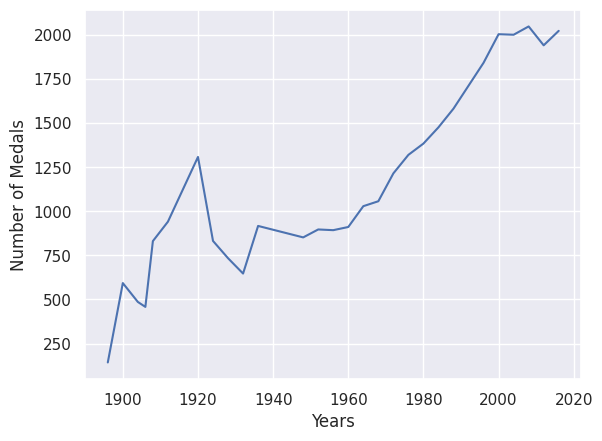

In [4]:
medal_athletes = df[df['Medal'].notna() & (df['Games'].str.contains('Summer'))]

number_medal_per_game = medal_athletes.drop_duplicates(['ID', 'Games', 'Sport', 'Event', 'Medal']).groupby('Year').size().reset_index(name='Medal_Count').sort_values('Year')

print(number_medal_per_game.head(10))
print(number_medal_per_game.columns)
sns.set(style='darkgrid')
ax = sns.lineplot(data=number_medal_per_game, x='Year', y='Medal_Count')
ax.set(xlabel='Years', ylabel='Number of Medals')
plt.show()

delete_df(medal_athletes)
delete_df(number_medal_per_game)

# *1.3 - TOP 10 SPORTS WITH MOST PARTICIPATIONS*

Index(['Sport', 'Participations'], dtype='object')
        Sport  Participations
0  Gymnastics              29
1   Athletics              29
2    Swimming              29
3     Cycling              29
4     Fencing              29
5      Rowing              28
6   Wrestling              28
7      Diving              27
8    Shooting              27
9    Football              27


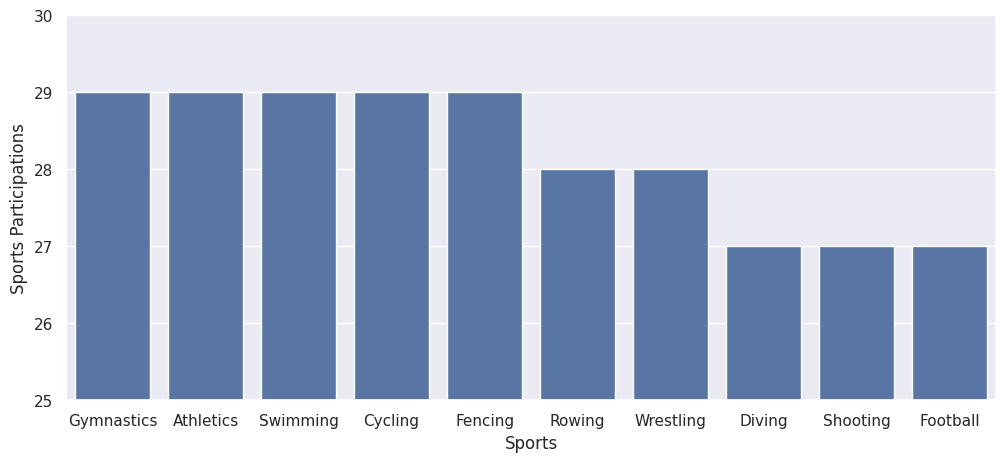

In [5]:
sports_participations = df.groupby('Sport')['Games'].nunique().reset_index(name='Participations').sort_values('Participations', ascending=False).head(10)

sports_participations = sports_participations.reset_index(drop=True)

print(sports_participations.columns)
print(sports_participations)

fig, ax = plt.subplots(figsize=(12, 5))
sns.set(style='darkgrid')
ax = sns.barplot(data=sports_participations, x='Sport', y='Participations')
ax.set(xlabel='Sports', ylabel='Sports Participations')
plt.ylim(sports_participations['Participations'].min() - 2, sports_participations['Participations'].max() + 1)
plt.show()

delete_df(sports_participations)

# *1.4 - SPORTS COUNT PER SUMMER OLYMPICS*

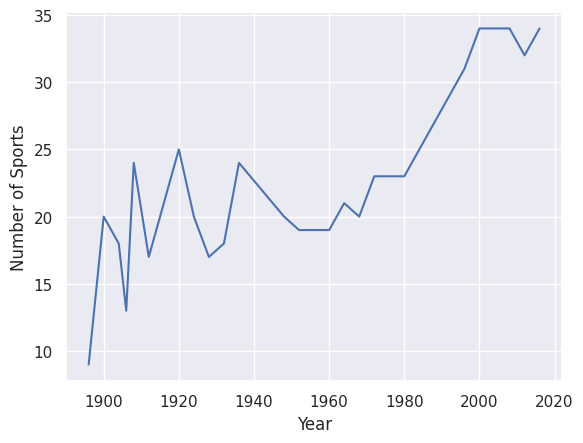

In [6]:
sports_per_games = df[df['Season'] == 'Summer'].groupby(['Year'])['Sport'].nunique().reset_index(name='Number of Sports').sort_values('Number of Sports', ascending=True)

sns.set(style='darkgrid')
ax = sns.lineplot(data=sports_per_games, x='Year', y='Number of Sports')
ax.set(ylabel='Number of Sports')
plt.show()

delete_df(sports_per_games)

# **SCRIPT 2 - WOMEN PRESENCE IN OLYMPICS**

# *2.1 - FIRST APPEARANCE*

In [7]:
FIRST_APPEARANCE = df[df['Sex'] == 'F'].groupby('Year')['ID'].size()

FIRST_APPEARANCE = FIRST_APPEARANCE.reset_index(name='Number of Athletes')

FIRST_APPEARANCE = FIRST_APPEARANCE['Year'].iloc[0]
print(f'First appearance of females athletes was in {FIRST_APPEARANCE}')

delete_df(FIRST_APPEARANCE)

First appearance of females athletes was in 1900


# *2.2 - GENDER PARTICIPATION OVER THE YEARS*

     Sex    ID  Percentage
Year                      
1896   M   176      100.00
1900   F    23        1.88
1900   M  1201       98.12
1904   F     6        0.92
1904   M   644       99.08


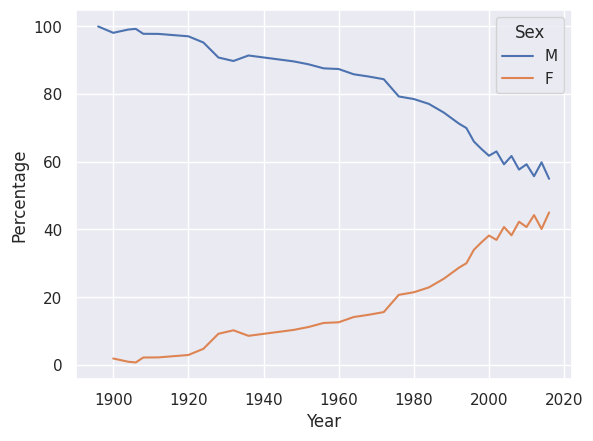

In [8]:
gender_years = df.groupby(['Year', 'Sex'])['ID'].nunique().reset_index('Sex').sort_values('Year')

gender_years['Percentage'] = np.round(gender_years['ID'] / gender_years.groupby('Year')['ID'].sum() * 100, 2)

print(gender_years.head())

sns.set(style='darkgrid')
ax = sns.lineplot(data=gender_years, x='Year', y='Percentage', hue='Sex')

plt.show()

delete_df(gender_years)

# *2.3 - SPORTS WITH MOST FEMALE ATHLETES*

             Sport  Number of Athletes
0        Athletics                6529
1         Swimming                3621
2       Gymnastics                1499
3           Rowing                1483
4       Volleyball                1129
5         Handball                1027
6    Alpine Skiing                 996
7           Hockey                 996
8       Basketball                 932
9          Fencing                 880
10  Figure Skating                 824
11            Judo                 757


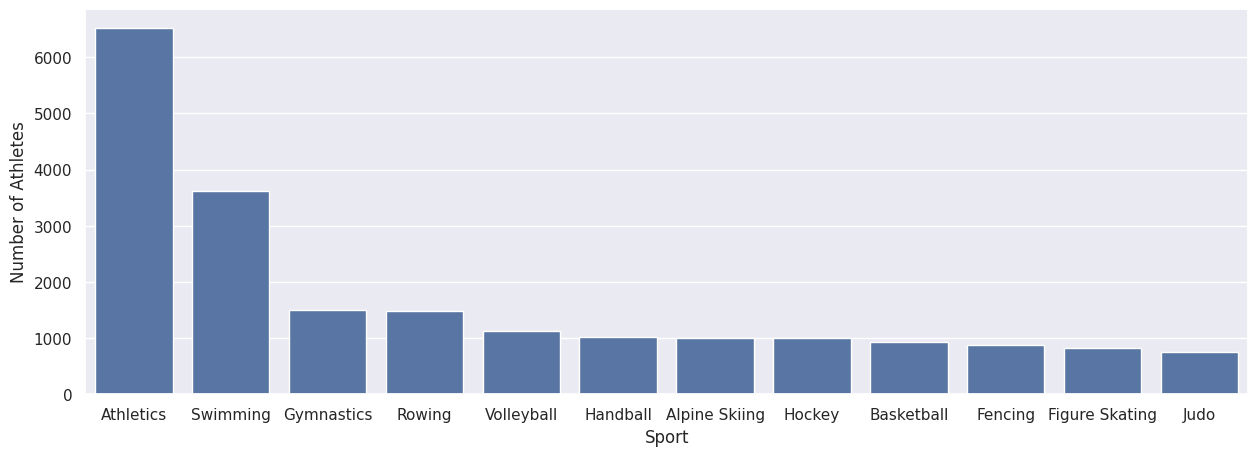

In [9]:
sport_most_women = df[df['Sex'] == 'F'].groupby('Sport')['ID'].nunique().reset_index(name='Number of Athletes').sort_values('Number of Athletes', ascending=False)
sport_most_women = sport_most_women[sport_most_women['Number of Athletes'] > 750].reset_index(drop=True)

print(sport_most_women)

fig, ax = plt.subplots(figsize=(15, 5))

sns.set(style='darkgrid')
ax = sns.barplot(data=sport_most_women, x='Sport', y='Number of Athletes')
plt.show()

delete_df(sport_most_women)

# *2.4 - MEN X WOMEN MEDALISTS*

   Year Sex  Medal  Percentage
0  1896   M    143      100.00
1  1900   F     13        2.19
2  1900   M    580       97.81
3  1904   F     10        2.06
4  1904   M    476       97.94
5  1906   F      6        1.31
6  1906   M    452       98.69
7  1908   F     16        1.93
8  1908   M    815       98.07
9  1912   F     30        3.19
Index(['Year', 'Sex', 'Medal', 'Percentage'], dtype='object')


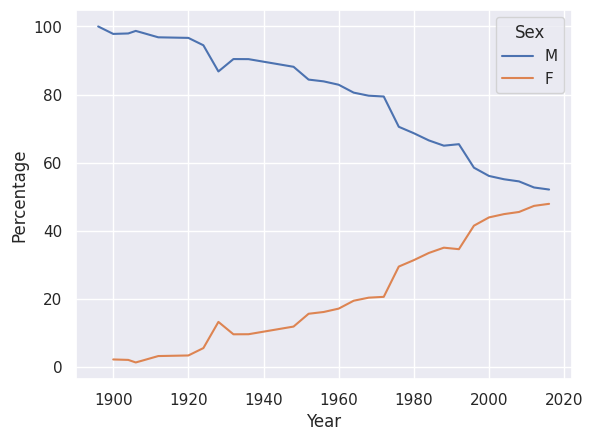

In [10]:
medal_athletes = df[df['Medal'].notna() & (df['Games'].str.contains('Summer'))]

number_medal_per_game = medal_athletes.drop_duplicates(['ID', 'Games', 'Event', 'Medal', 'Year']).groupby(['Year', 'Sex']).size().reset_index(name='Medal').sort_values('Year')

number_medal_per_game['Percentage'] = np.round(100*number_medal_per_game['Medal']/number_medal_per_game.groupby('Year')['Medal'].transform('sum'), 2)

print(number_medal_per_game.head(10))
print(number_medal_per_game.columns)

sns.set(style='darkgrid')
ax = sns.lineplot(data=number_medal_per_game, x='Year', y='Percentage', hue='Sex')

plt.show()

delete_df(medal_athletes)
delete_df(number_medal_per_game)

# 2.5 - *TOP 20 COUNTRIES WITH MOST FEMALES PRESENCE*

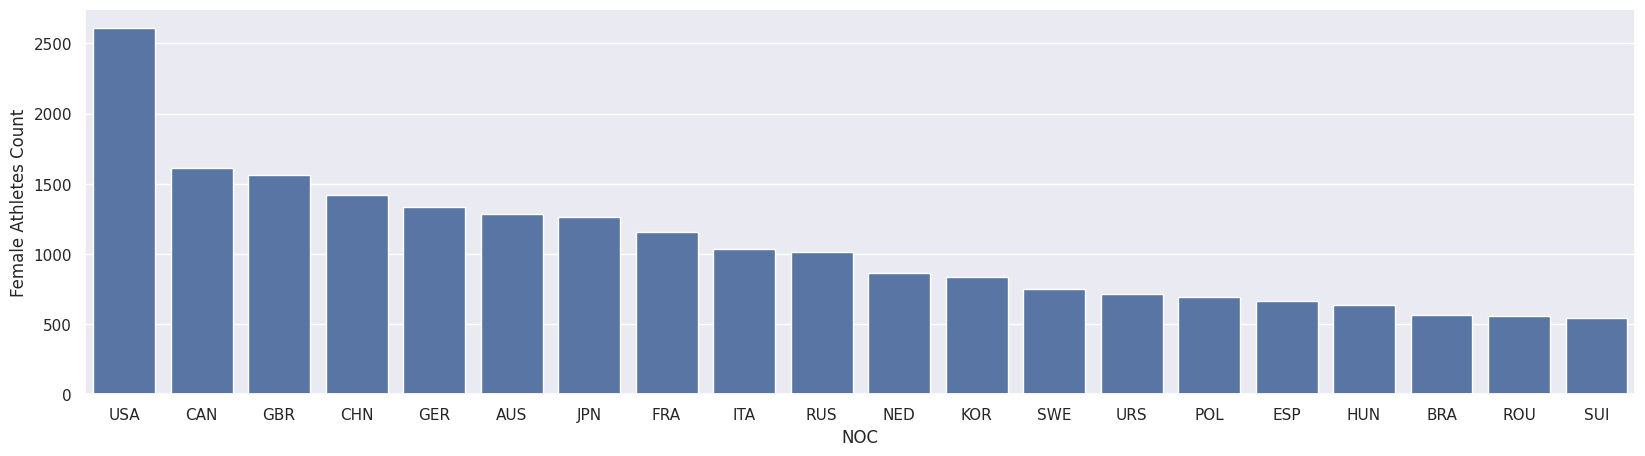

In [11]:
countries_female_presence = df[df['Sex'] == 'F'].groupby('NOC')['ID'].nunique().reset_index(name='Female Athletes Count').sort_values(ascending=False, by='Female Athletes Count').head(20)
countries_female_presence = countries_female_presence.reset_index(drop=True)

sns.set(style='darkgrid')
fig, ax2 = plt.subplots(figsize=(20, 5))
ax = sns.barplot(ax=ax2, data=countries_female_presence, x='NOC', y='Female Athletes Count')
plt.show()

delete_df(countries_female_presence)

# **SCRIPT 3 - GROWTH EVALUATIONS**
# *3.1 - NUMBER OF EVENTS PER DECADE*

    Decades  Events
0      2010     410
1      2000     404
2      1990     351
3      1980     293
4      1970     246
5      1900     237
6      1960     220
7      1920     215
8      1950     180
9      1940     175
10     1930     174
11     1910     107
12     1890      43


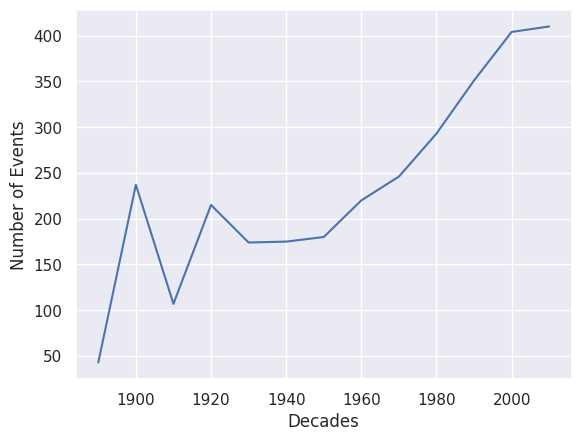

In [12]:
df['Decades'] = (df['Year'].values // 10) * 10

events_per_decade = df.groupby('Decades')['Event'].nunique().reset_index(name='Events').sort_values(ascending=False, by='Events')
events_per_decade = events_per_decade.reset_index(drop=True)

print(events_per_decade)

sns.set(style='darkgrid')
ax = sns.lineplot(data=events_per_decade, x='Decades', y='Events')
ax.set(xlabel='Decades', ylabel='Number of Events')

plt.show()

delete_df(events_per_decade)

# *3.2 - GROWTH RATE FOR FEMALE ATHLETES THROUGHOUT THE DECADES*

    Decades  Female Athletes   Before  Growth Percentage Result
0      1900               79      NaN                NaN      =
1      1910               53     79.0             -32.91      -
2      1920              526     53.0             892.45      +
3      1930              617    526.0              17.30      +
4      1940              523    617.0             -15.24      -
5      1950             1021    523.0              95.22      +
6      1960             2179   1021.0             113.42      +
7      1970             2477   2179.0              13.68      +
8      1980             4957   2477.0             100.12      +
9      1990             6579   4957.0              32.72      +
10     2000            11422   6579.0              73.61      +
11     2010             9686  11422.0             -15.20      -


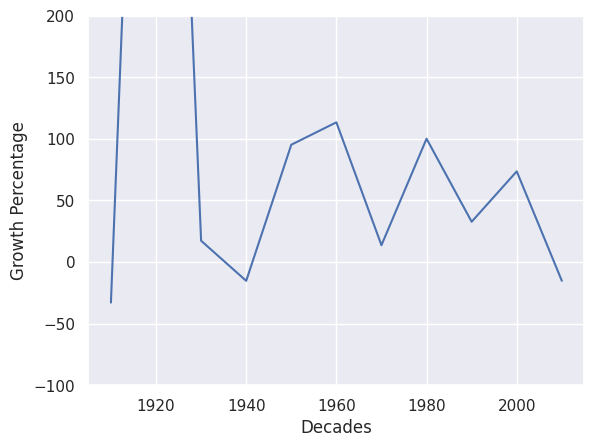

In [13]:
female_per_decade = df[df['Sex'] == 'F'].groupby('Decades')['ID'].nunique().reset_index(name='Female Athletes').sort_values(ascending=True, by='Decades')
female_per_decade = female_per_decade.reset_index(drop=True)

female_per_decade['Before'] = female_per_decade['Female Athletes'].shift(1)

female_per_decade['Growth Percentage'] = np.round(100*(female_per_decade['Female Athletes'] - female_per_decade['Before']) / female_per_decade['Before'], 2)
female_per_decade['Result'] = np.where(female_per_decade['Growth Percentage'] > 0, '+', np.where(female_per_decade['Growth Percentage'] < 0, '-', '='))

print(female_per_decade)

sns.set(style='darkgrid')
ax = sns.lineplot(data=female_per_decade, x='Decades', y='Growth Percentage')
plt.ylim(-100, 200)
plt.show()

delete_df(female_per_decade)

# *3.3 - NUMBER OF ATHLETES & AVERAGE AGE BY EACH OLYMPICS*

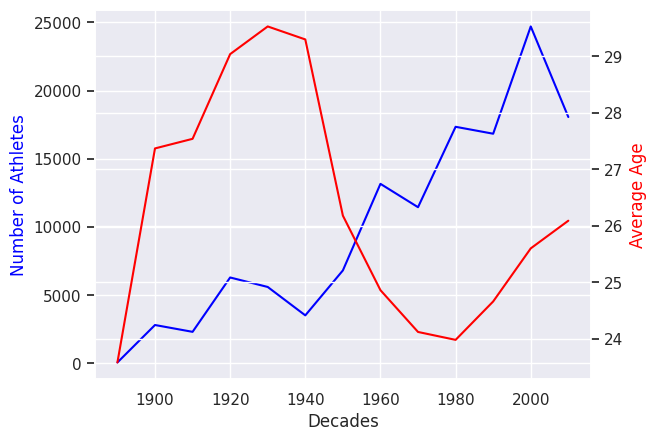

In [14]:
num_age_athletes = df[(df['Season'] == 'Summer') & (df['Age'] > 0)].groupby('Decades').agg(Count_Athletes = ('ID', 'nunique'), Avg_age=('Age', 'mean')).round({'Avg_age': 2}).reset_index()

sns.set(style='darkgrid')
ax = sns.lineplot(data=num_age_athletes, x='Decades', y='Count_Athletes', color='blue')
ax.set_ylabel('Number of Athletes', color='blue')

ax2 = ax.twinx()
ax2 = sns.lineplot(data=num_age_athletes, x='Decades', y='Avg_age', color='red')
ax2.set_ylabel('Average Age', color='red')
plt.show()

delete_df(num_age_athletes)

# *3.4 - GOLD MEDALS THROUGH THE DECADES*

   Year  Total Gold Medals  Percentage  Cummulative
0  1896                 43         NaN           43
1  1900                 89      106.98          132
2  1904                 95        6.74          227
3  1906                 74      -22.11          301
4  1908                109       47.30          410


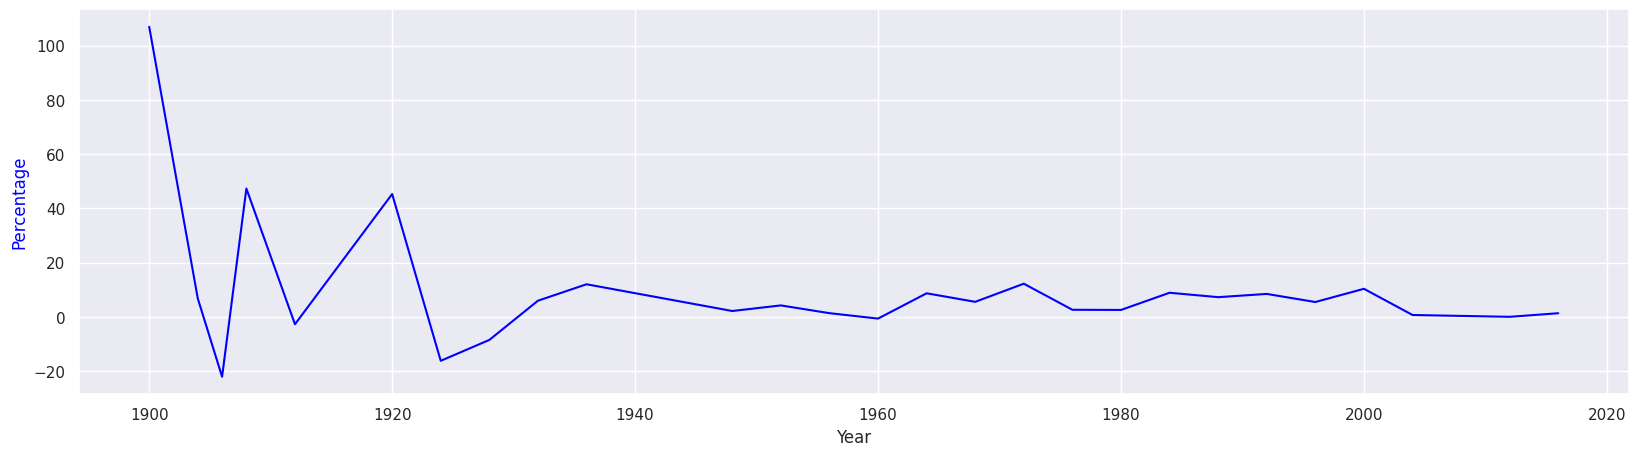

In [15]:
gold_medals_per_decade = df[(df['Medal'] == 'Gold') & (df['Games'].str.contains('Summer'))].drop_duplicates(['Games', 'Event']).groupby('Year').size().reset_index(name='Total Gold Medals').sort_values('Year')

gold_medals_per_decade['Percentage'] = np.round(100 * (gold_medals_per_decade['Total Gold Medals'] - gold_medals_per_decade['Total Gold Medals'].shift(1))/gold_medals_per_decade['Total Gold Medals'].shift(1),2)

gold_medals_per_decade['Cummulative'] = gold_medals_per_decade['Total Gold Medals'].cumsum()

print(gold_medals_per_decade.head())

fig, ax = plt.subplots(figsize=(20, 5))

sns.lineplot(data=gold_medals_per_decade, x='Year', y='Percentage', color='blue')
ax.set_ylabel('Percentage', color='blue')

plt.show()

delete_df(gold_medals_per_decade)

## *3.5 - TOTAL FEMALES X MALES ATHLETES PERCENTAGE THROUGH THE DECADES*

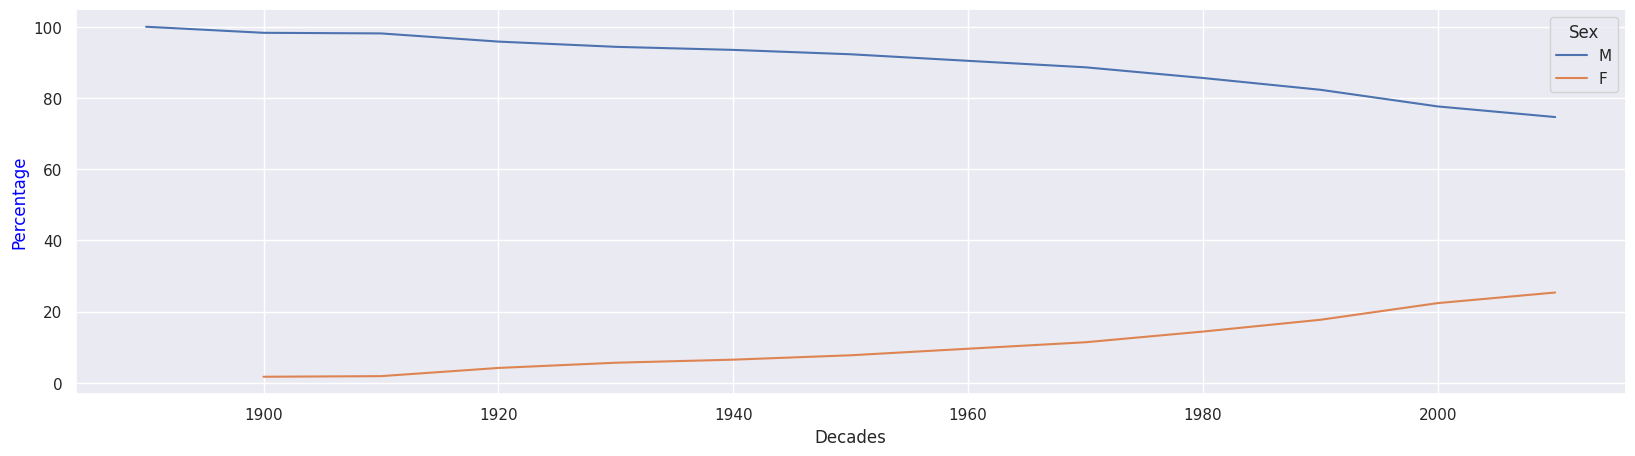

In [16]:
athletes_per_sex = df.groupby(['Decades', 'Sex'])['ID'].nunique().reset_index('Sex').sort_values('Decades')

athletes_per_sex['Cummulative per Sex'] = athletes_per_sex.groupby('Sex')['ID'].cumsum()

athletes_per_sex['Percentage'] = np.round(100 * athletes_per_sex['Cummulative per Sex'] / athletes_per_sex.groupby(['Decades'])['Cummulative per Sex'].sum(), 2)

fig, ax = plt.subplots(figsize=(20, 5))
sns.lineplot(data=athletes_per_sex, x='Decades', y='Percentage', hue='Sex')
ax.set_ylabel('Percentage', color='blue')
plt.show()

delete_df(athletes_per_sex)

# **SCRIPT 4 - ANALYSIS PER COUNTRY**
# *4.1 - OVERALL RANKING PER COUNTRY (GOLD MEDALS)*

       F    M  Total
NOC                 
USA  307  817   1124
URS  127  334    461
GER  101  214    315
GBR   55  231    286
FRA   42  222    264
ITA   38  216    254
CHN  138  100    238
RUS   87  115    202
SWE   24  174    198
GDR   94   98    192
HUN   43  133    176
NOR   25  142    167
JPN   35  117    152
AUS   63   87    150
FIN   13  132    145
NED   61   64    125
CAN   47   75    122
KOR   52   64    116
SUI   19   89    108
ROU   58   30     88


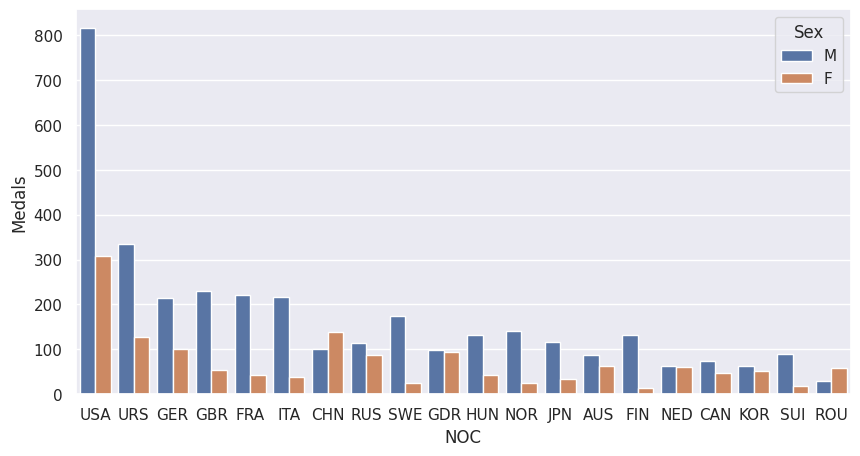

In [17]:
medal_athletes = df[df['Medal'] == 'Gold'].drop_duplicates(['Games','Event']).groupby(['NOC', 'Sex']).size().unstack(fill_value=0)

medal_athletes['Total'] = (medal_athletes['M'] + medal_athletes['F'])

medal_athletes = medal_athletes.sort_values('Total', ascending=False).head(20)
medal_athletes.columns.name = None

print(medal_athletes)

fig, ax = plt.subplots(figsize=(10, 5))

medal_plot = medal_athletes.reset_index().melt(id_vars='NOC', var_name='Sex', value_name='Medals', value_vars=['M', 'F'])

sns.barplot(data=medal_plot, x='NOC', y='Medals', hue='Sex')

plt.show()

delete_df(medal_athletes)
delete_df(medal_plot)

# *4.2 - TOP 50 MOST TOTAL MEDALS PER TEAM (ALL MEDALS)*

     Gold  Silver  Bronze  Total  Total Points
NOC                                           
USA  1131     901     791   2823          5986
URS   471     373     353   1197          2512
GER   319     345     340   1004          1987
GBR   289     320     310    919          1817
FRA   264     286     329    879          1693
ITA   256     225     241    722          1459
SWE   200     215     242    657          1272
CHN   239     184     172    595          1257
RUS   202     183     199    584          1171
GDR   192     165     162    519          1068
HUN   178     156     176    510          1022
AUS   153     170     196    519           995
NOR   167     159     148    474           967
JPN   152     151     179    482           937
FIN   146     148     177    471           911
CAN   126     160     189    475           887
NED   125     133     149    407           790
SUI   108     122     116    346           684
KOR   116     102      98    316           650
AUT    85    

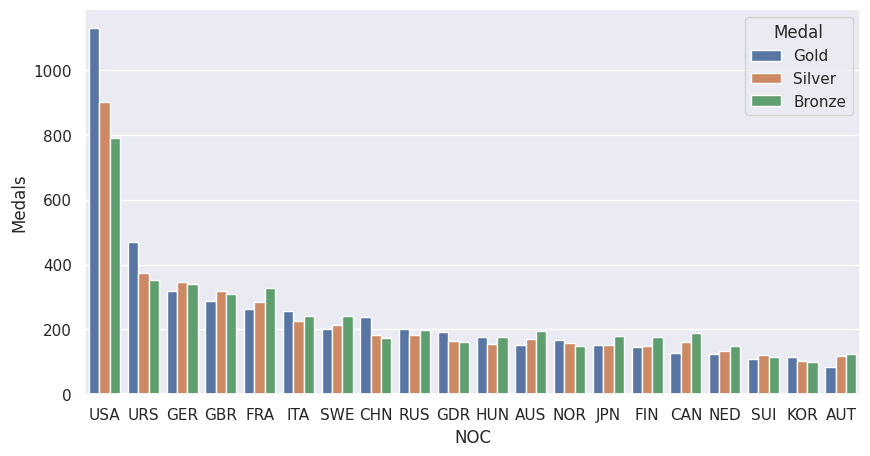

In [18]:
all_medal_athletes = df[df['Medal'].notna()].drop_duplicates(['Games', 'Sport','Event', 'NOC', 'Medal']).groupby(['NOC', 'Medal']).size().unstack(fill_value=0)

all_medal_athletes = all_medal_athletes.iloc[:, [1,2,0]]

all_medal_athletes['Total'] = (all_medal_athletes['Gold'] + all_medal_athletes['Silver'] + all_medal_athletes['Bronze'])
all_medal_athletes['Total Points'] = 3*all_medal_athletes['Gold'] + 2*all_medal_athletes['Silver'] + all_medal_athletes['Bronze']
all_medal_athletes = all_medal_athletes.sort_values('Total Points', ascending=False).head(20)
all_medal_athletes.columns.name = None

print(all_medal_athletes)

all_medal_plot = all_medal_athletes.reset_index().melt(id_vars='NOC', var_name='Medal', value_name='Medals', value_vars=['Gold', 'Silver', 'Bronze'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=all_medal_plot, x='NOC', y='Medals', hue='Medal')
plt.show()

delete_df(all_medal_athletes)
delete_df(all_medal_plot)


# *4.3 - EACH OLYMPICS TOP 10 RANKING*

In [19]:
ranking = df[(df['Medal'] == 'Gold') & (df['Season'].str.contains('Summer'))].drop_duplicates(['Games', 'Sport', 'Event', 'NOC', 'Medal']).groupby(['Year', 'NOC']).size().reset_index(name='Medals').sort_values(['Year', 'Medals'], ascending=False)

ranking = ranking.groupby('Year').head(10).reset_index(drop=True)

ranking['Rank'] = ranking.groupby('Year')['Medals'].rank(ascending=False, method='min').astype(int)

year = int(input('Insert Year: '))
print(choose_year(year, ranking))

delete_df(ranking)

Insert Year: 2012
   Year  NOC  Medals  Rank
0  2012  USA      46     1
1  2012  CHN      38     2
2  2012  GBR      29     3
3  2012  RUS      24     4
4  2012  KOR      13     5
5  2012  FRA      11     6
6  2012  GER      11     6
7  2012  HUN       8     8
8  2012  ITA       8     8
9  2012  AUS       7    10


# *4.4 - MEDALS PER (ATHLETE x COUNTRY x YEAR) METRIC*

[1896 1900 1904 1906 1908 1912 1920 1924 1928 1932 1936 1948 1952 1956
 1960 1964 1968 1972 1976 1980 1984 1988 1992 1994 1996 1998 2000 2002
 2004 2006 2008 2010 2012 2014 2016]	Insert Year: 2012
   NOC  Year  Count_Athletes  Count_Medal  Medal per Athlete
0  USA  2012             530          248               0.47
1  NED  2012             173           69               0.40
2  CHN  2012             375          125               0.33
3  CRO  2012             107           35               0.33
4  RUS  2012             429          140               0.33
5  JPN  2012             291           84               0.29
6  AUS  2012             405          114               0.28
7  NOR  2012              61           17               0.28
8  FRA  2012             324           82               0.25
9  GER  2012             383           94               0.25


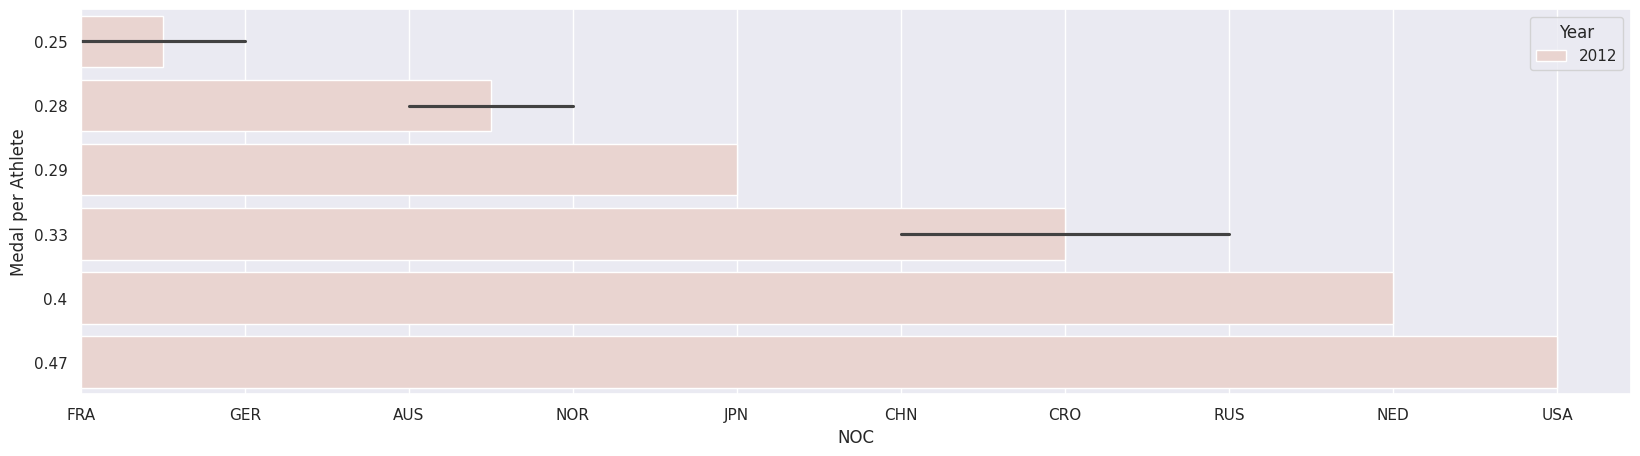

In [20]:
# This counts medals for all athletes for team games (Football, Basketball)

medal_per_athlete = (
    df.drop_duplicates(['ID', 'Games','Sport','Event', 'Year'])
    .groupby(['NOC', 'Year'])
    .agg(
        Count_Athletes = ('ID', 'nunique'),
        Count_Medal=('Medal', 'count'))
    .reset_index()
  )
medal_per_athlete = medal_per_athlete[medal_per_athlete['Count_Athletes'] > 50]
medal_per_athlete['Medal per Athlete'] = np.round(medal_per_athlete['Count_Medal'] / medal_per_athlete['Count_Athletes'], 2)
medal_per_athlete = medal_per_athlete.sort_values(['Year', 'Medal per Athlete'], ascending=[True, False]).reset_index(drop=True)
medal_per_athlete = medal_per_athlete.groupby('Year').head(10).reset_index(drop=True)


print(medal_per_athlete['Year'].sort_values().unique(), end='\t')
year = int(input('Insert Year: '))
medal_per_athlete = choose_year(year, medal_per_athlete)

print(medal_per_athlete)
# year = int(input('Insert Year: '))
# print(choose_year(year, medal_per_athlete))

fig, ax = plt.subplots(figsize=(20, 5))
sns.barplot(data=medal_per_athlete, x='NOC', y='Medal per Athlete', hue='Year', orient='h')
plt.show()

delete_df(medal_per_athlete)

# *4.5 - EACH COUNTRY ESPECIALITY*

                        Sport  NOC  Count_Medal
0                   Athletics  USA          344
1                    Swimming  USA          246
2                  Gymnastics  URS           71
3                   Wrestling  URS           62
4                    Shooting  USA           54
5                      Boxing  USA           50
6                     Fencing  ITA           49
7                      Diving  USA           48
8                     Cycling  FRA           42
9               Weightlifting  URS           39
10                       Judo  JPN           39
11                   Canoeing  GER           36
12              Speed Skating  NED           35
13              Alpine Skiing  AUT           34
14                     Rowing  USA           33
15       Cross Country Skiing  NOR           33
16              Equestrianism  GER           30
17               Table Tennis  CHN           28
18                    Sailing  GBR           28
19                 Basketball  USA      

<Axes: title={'center': 'Top 30 Most Golden Medal Sport by Countries'}, xlabel='NOC', ylabel='Sport'>

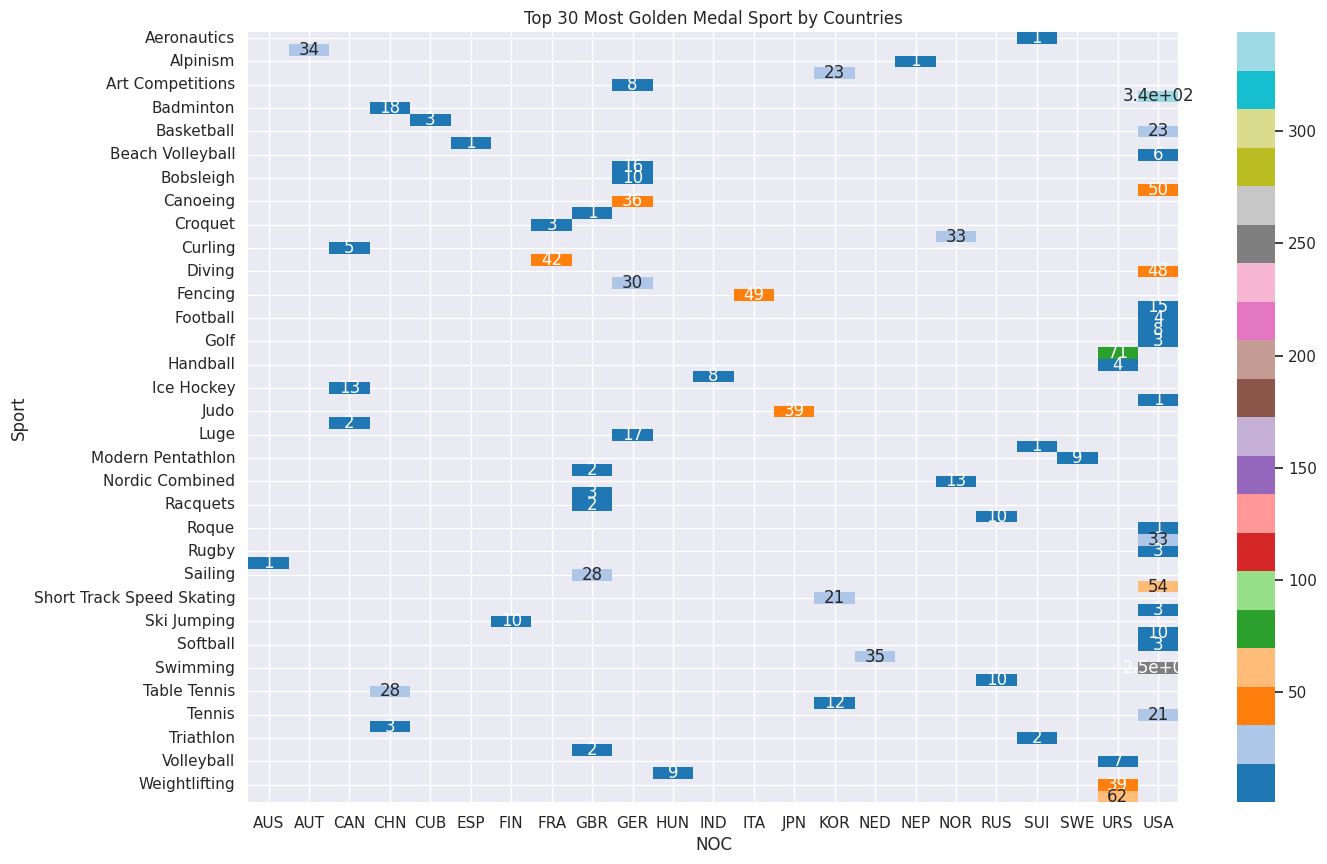

In [21]:
country_speciality = (
    df[df['Medal'] == 'Gold']
    .drop_duplicates(['Games','Sport','Event','NOC']).
    groupby(['Sport', 'NOC'])
    .agg(
        Count_Medal=('Medal', 'count'))
    .sort_values('Sport', ascending=True)
    .reset_index()
  )

country_speciality = country_speciality.loc[country_speciality.groupby('Sport')['Count_Medal'].idxmax()].sort_values('Count_Medal', ascending=False).reset_index(drop=True)
countries_speciality = country_speciality[country_speciality['Count_Medal'] > 10]

print(countries_speciality)


fig, ax = plt.subplots(figsize=(15, 10))
plt.title('Top 30 Most Golden Medal Sport by Countries')
sns.heatmap(data=country_speciality.pivot(index='Sport', columns='NOC', values='Count_Medal'), annot=True, cmap='tab20')

# *4.6 - SUMMER X WINTER ATHLETE COUNT & PERCENTAGE BY DECADE*

Season    Summer  Winter  Percentage Summer  Percentage Winter
Decades                                                       
1920      8058.0   708.0              91.92               8.08
1930      5999.0   856.0              87.51              12.49
1940      4402.0   668.0              86.82              13.18
1950      7466.0  1333.0              84.85              15.15
1960     13403.0  2360.0              85.03              14.97
1970     11565.0  1850.0              86.21              13.79
1980     17756.0  3023.0              85.45              14.55
1990     16878.0  4125.0              80.36              19.64
2000     24709.0  3893.0              86.39              13.61
2010     18067.0  4176.0              81.23              18.77


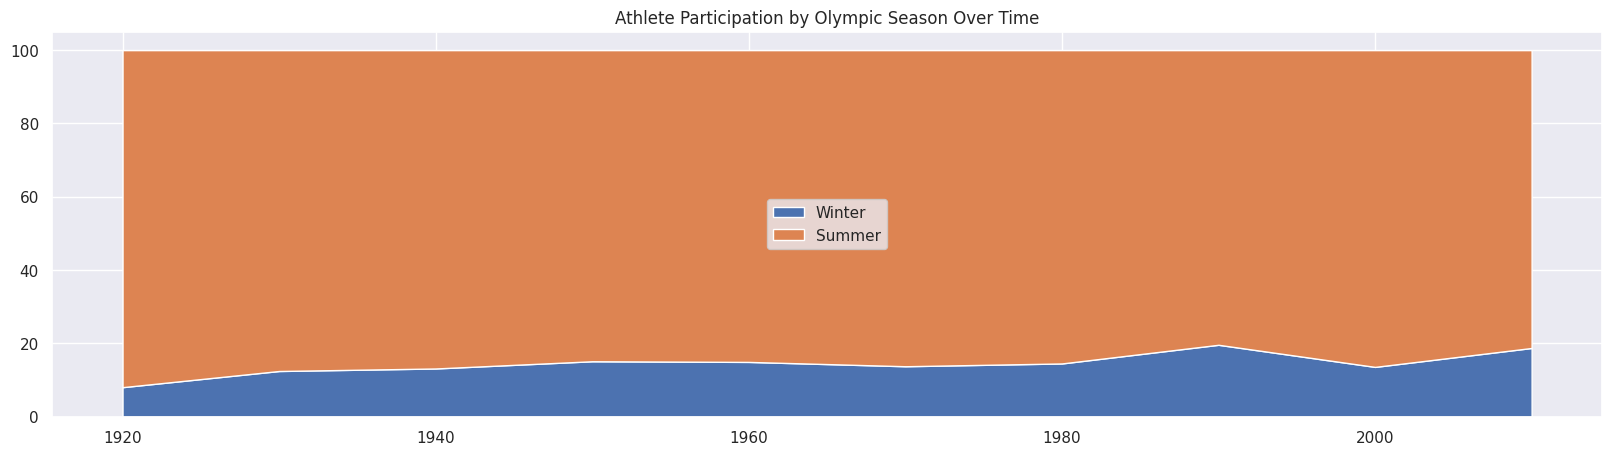

In [22]:
season_per_decade = df.groupby(['Decades', 'Season'])['ID'].nunique().reset_index(name="Count").sort_values('Decades')

season_per_decade = season_per_decade.pivot(index='Decades', columns='Season', values='Count').dropna()

season_per_decade['Percentage Summer'] = np.round(100 * season_per_decade['Summer']/(season_per_decade['Summer'] + season_per_decade['Winter']), 2)
season_per_decade['Percentage Winter'] = 100 - season_per_decade['Percentage Summer']

print(season_per_decade)

fig, ax = plt.subplots(figsize=(20, 5))
plt.title('Athlete Participation by Olympic Season Over Time')
plt.stackplot(season_per_decade.index, season_per_decade['Percentage Winter'], season_per_decade['Percentage Summer'], labels=['Winter', 'Summer'])

plt.legend()
plt.show()

delete_df(season_per_decade)

# **SCRIPT 5 - PHYSICAL ANALYSIS**

# *5.1 - AVERAGE HEIGHT AND WEIGHT PER SPORT (MEDAL ATHLETES)*

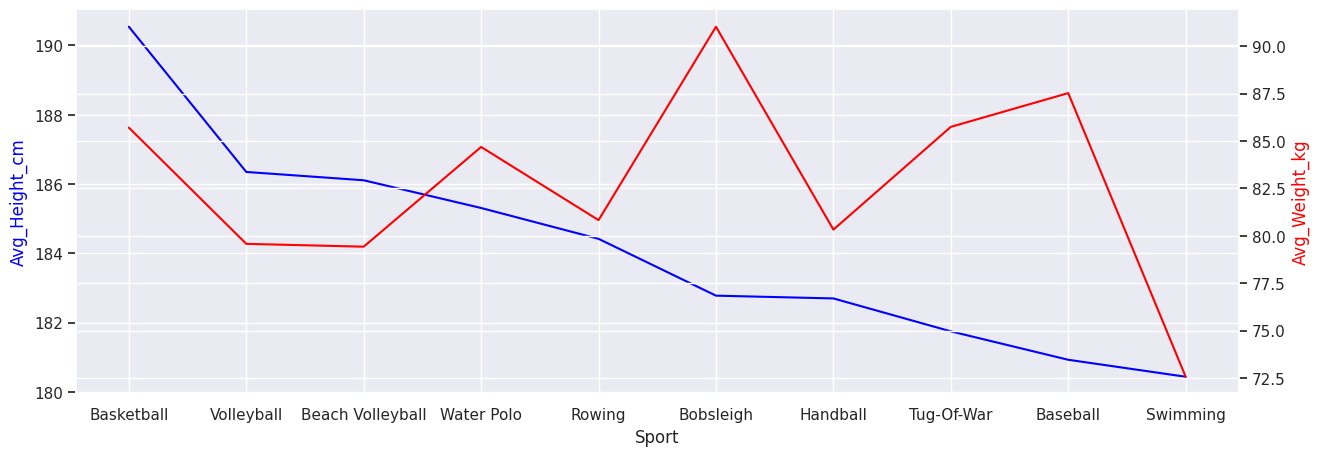

In [23]:
medal_athletes = (
    df[df['Medal'].isin(['Gold', 'Silver', 'Bronze']) & (df['Height'] > 0.0) & (df['Weight'] > 0.0)]
    .drop_duplicates(['Year', 'Sport', 'Event', 'NOC', 'Medal'])
    .groupby(['Sport'])
    .agg(
        Avg_Height_cm = ('Height', 'mean'),
        Avg_Weight_kg = ('Weight', 'mean'),
    )
    .round({"Avg_Height_cm": 2,
           "Avg_Weight_kg": 2})
    .sort_values('Avg_Height_cm', ascending=False)
    .reset_index().head(10)
    )

medal_athletes

fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(data=medal_athletes, x='Sport', y='Avg_Height_cm', color='blue', ax=ax)
ax.set_ylabel('Avg_Height_cm', color='blue')
ax2 = ax.twinx()

sns.lineplot(data=medal_athletes, x='Sport', y='Avg_Weight_kg', color='red', ax=ax2)
ax2.set_ylabel('Avg_Weight_kg', color='red')

plt.show()

# *5.2 - MEDALIST X NON_MEDALIST*



In [61]:
medal_df = df[(df['Height'] > 0.0 ) & (df['Weight'] > 0.0)].copy()

medal_df['Medal Status'] = np.where(medal_df['Medal'].notna(), 'Medal', 'Non Medal')

medal_df = (
    medal_df
    .drop_duplicates(['ID', 'Year', 'Sport', 'Event'])
    .groupby(['Medal Status', 'Sport', 'Sex'])
    .agg(
        Avg_Height_cm = ('Height', 'mean'),
        Avg_Weight_kg = ('Weight', 'mean')
    )
    .round(
        {"Avg_Height_cm": 2,
         "Avg_Weight_kg": 2})
    .reset_index()

  )

pivot_df = (medal_df
    .pivot(index=['Sport', 'Sex'], columns='Medal Status', values=['Avg_Height_cm', 'Avg_Weight_kg'])
    )

pivot_df['Height Percentage Diff'] = np.round(100*(pivot_df[('Avg_Height_cm', 'Medal')] - pivot_df[('Avg_Height_cm', 'Non Medal')])/pivot_df[('Avg_Height_cm', 'Non Medal')], 2)

pivot_df['Weight Percentage Diff'] = np.round(100*(pivot_df[('Avg_Weight_kg', 'Medal')] - pivot_df[('Avg_Weight_kg', 'Non Medal')])/pivot_df[('Avg_Weight_kg', 'Non Medal')], 2)

pivot_df = pivot_df.reset_index()

pivot_df.columns = [
    f"{a}_{b}" if isinstance(a, str) and b else a
    for a,b in pivot_df.columns.to_flat_index()
]

pivot_df = pivot_df.sort_values(['Sport', 'Sex'], ascending=[True, False])

pivot_df = pivot_df.fillna(0).reset_index(drop=True)

print(pivot_df)

delete_df(pivot_df)
delete_df(medal_df)


                Sport Sex  Avg_Height_cm_Medal  Avg_Height_cm_Non Medal  \
0       Alpine Skiing   M               179.25                   177.83   
1       Alpine Skiing   F               168.26                   167.15   
2             Archery   M               179.21                   178.54   
3             Archery   F               167.14                   167.20   
4    Art Competitions   M               174.00                   172.93   
..                ...  ..                  ...                      ...   
97         Water Polo   F               175.85                   175.38   
98      Weightlifting   M               169.26                   169.13   
99      Weightlifting   F               160.08                   160.58   
100         Wrestling   M               173.39                   172.81   
101         Wrestling   F               163.82                   163.88   

     Avg_Weight_kg_Medal  Avg_Weight_kg_Non Medal  Height Percentage Diff  \
0                  81.

# *5.3 - AVERAGE AGE PER SEX & SPORT (MEDALIST x NON MEDALIST)*

Medal Status       Medal  Non Medal
Sport         Sex                  
Aeronautics   M    26.00       0.00
Alpine Skiing F    23.33      22.27
              M    25.34      23.69
Alpinism      F    43.00       0.00
              M    38.53       0.00
...                  ...        ...
Water Polo    M    26.04      25.63
Weightlifting F    23.67      24.13
              M    25.60      25.73
Wrestling     F    25.93      25.13
              M    26.09      25.76

[116 rows x 2 columns]


/tmp/ipykernel_6671/2630199811.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')


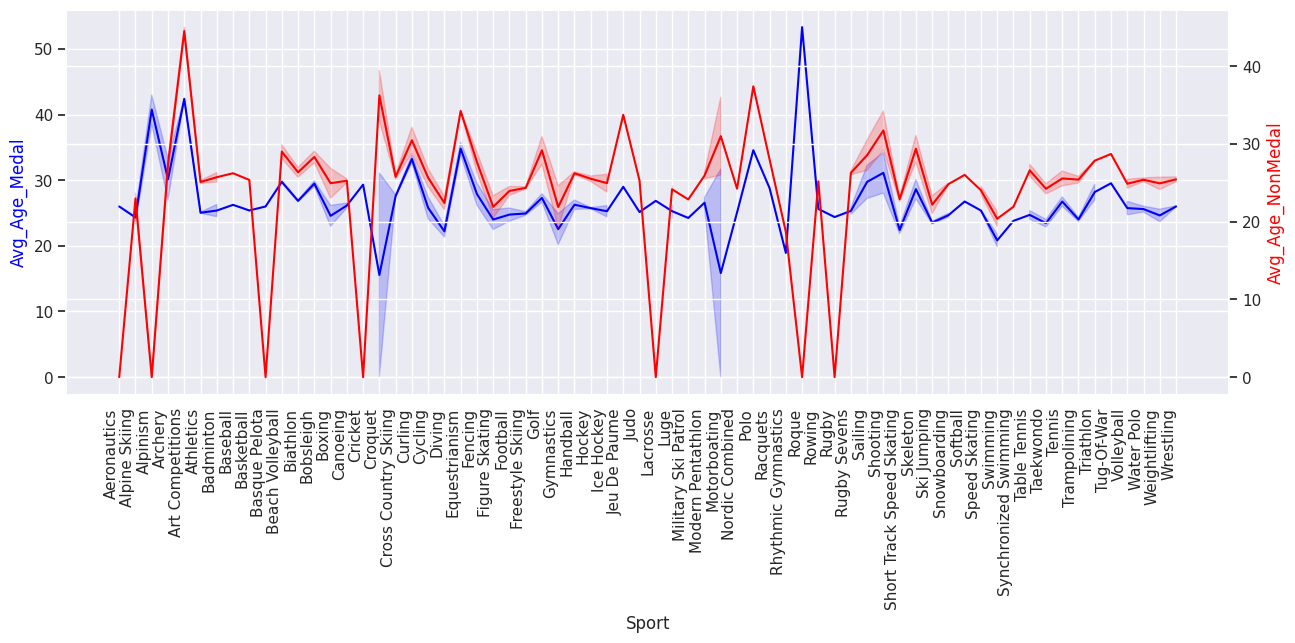

In [51]:
medal_df = df.copy()

medal_df['Medal Status'] = np.where(medal_df['Medal'].notna(), 'Medal', 'Non Medal')

medal_df = (medal_df.drop_duplicates(['ID', 'Year', 'Sport', 'Event'])
    .groupby(['Medal Status', 'Sport', 'Sex'])
    .agg(
        Avg_Age = ('Age', 'mean')
    )
    .round({
        "Avg_Age": 2}
    )
    .fillna(0)
    .reset_index()
    )


pivot_df = medal_df.pivot(index=['Sport', 'Sex'], columns='Medal Status', values='Avg_Age').fillna(0)


print(pivot_df)

medal_df

fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(data=pivot_df, x='Sport', y='Medal', color='blue', ax=ax)
ax.set_ylabel('Avg_Age_Medal', color='blue')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='right')
ax2 = ax.twinx()

sns.lineplot(data=pivot_df, x='Sport', y='Non Medal', color='red', ax=ax2, legend=False)
ax2.set_ylabel('Avg_Age_NonMedal', color='red')

plt.show()



# *5.4 - AGE PEAK BY SPORTS*

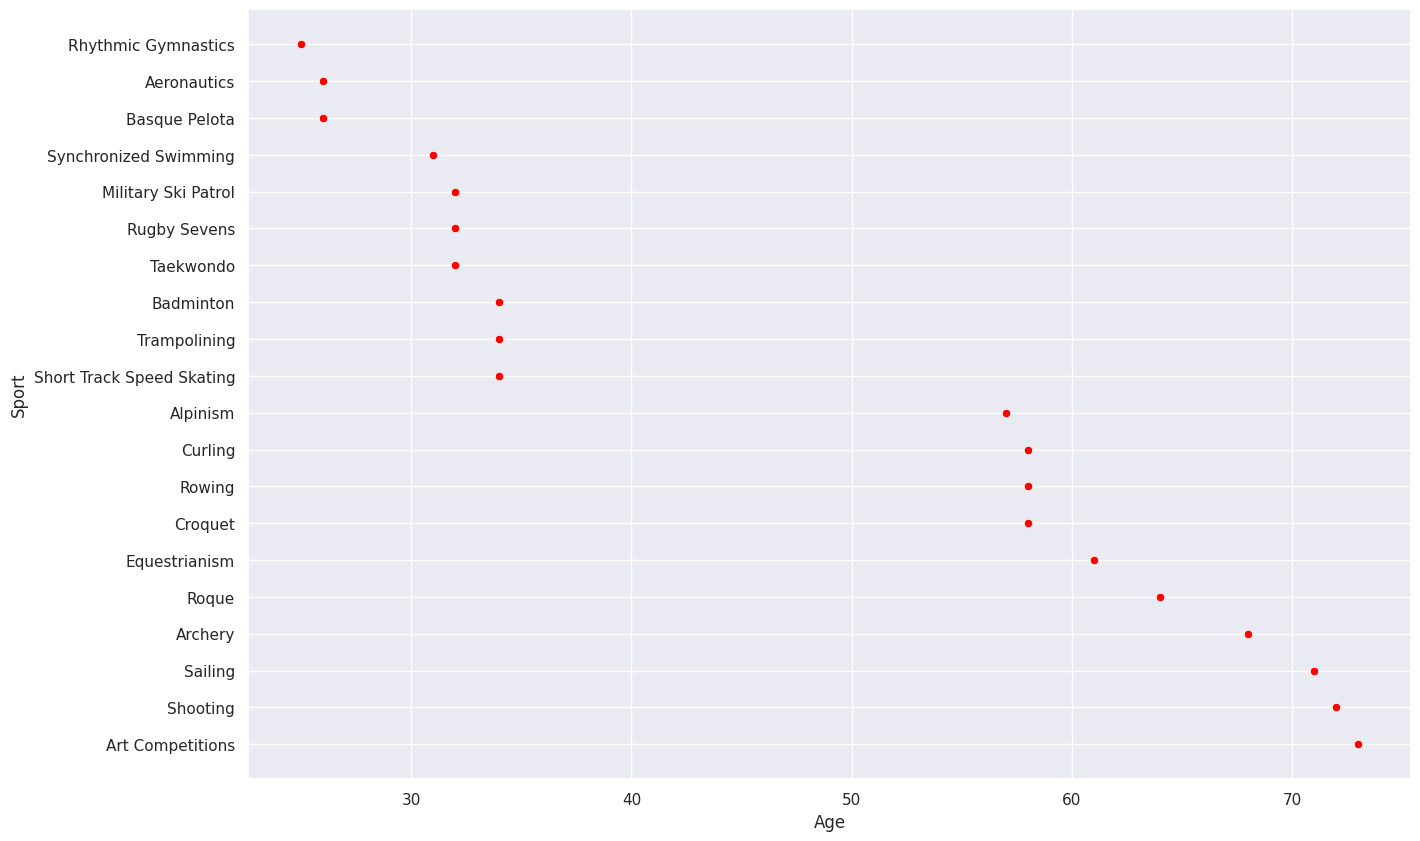

                    Sport   Age
0     Rhythmic Gymnastics  25.0
1             Aeronautics  26.0
2           Basque Pelota  26.0
3   Synchronized Swimming  31.0
4     Military Ski Patrol  32.0
..                    ...   ...
61                  Roque  64.0
62                Archery  68.0
63                Sailing  71.0
64               Shooting  72.0
65       Art Competitions  73.0

[66 rows x 2 columns]


In [41]:
age_peak = df[df['Medal'].notna() & df['Age'] > 0].groupby(['Sport'])['Age'].max().reset_index(name='Age').sort_values('Age').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(15, 10))
# sns.boxplot(data=age_peak, x='Sport', y= 'Age', ax=ax, orient='y')
sns.scatterplot(data=pd.concat([age_peak.head(10), age_peak.tail(10)]), x='Age', y='Sport', color='red', ax=ax)
plt.show()
print(age_peak)

delete_df(age_peak)

# *5.5 - PHYSICAL EVOLUTION PER SPORT*

Options: ['Alpine Skiing' 'Archery' 'Art Competitions' 'Athletics' 'Badminton'
 'Baseball' 'Basketball' 'Beach Volleyball' 'Biathlon' 'Bobsleigh'
 'Boxing' 'Canoeing' 'Cross Country Skiing' 'Curling' 'Cycling' 'Diving'
 'Equestrianism' 'Fencing' 'Figure Skating' 'Football' 'Freestyle Skiing'
 'Golf' 'Gymnastics' 'Handball' 'Hockey' 'Ice Hockey' 'Jeu De Paume'
 'Judo' 'Lacrosse' 'Luge' 'Modern Pentathlon' 'Motorboating'
 'Nordic Combined' 'Polo' 'Racquets' 'Rhythmic Gymnastics' 'Rowing'
 'Rugby' 'Rugby Sevens' 'Sailing' 'Shooting' 'Short Track Speed Skating'
 'Skeleton' 'Ski Jumping' 'Snowboarding' 'Softball' 'Speed Skating'
 'Swimming' 'Synchronized Swimming' 'Table Tennis' 'Taekwondo' 'Tennis'
 'Trampolining' 'Triathlon' 'Tug-Of-War' 'Volleyball' 'Water Polo'
 'Weightlifting' 'Wrestling']
Insert Sport: Football
    Year  Avg_Height
0   1908      182.00
1   1912      173.88
2   1920      174.92
3   1924      173.33
4   1928      173.03
5   1936      173.18
6   1948      174.85
7   1952

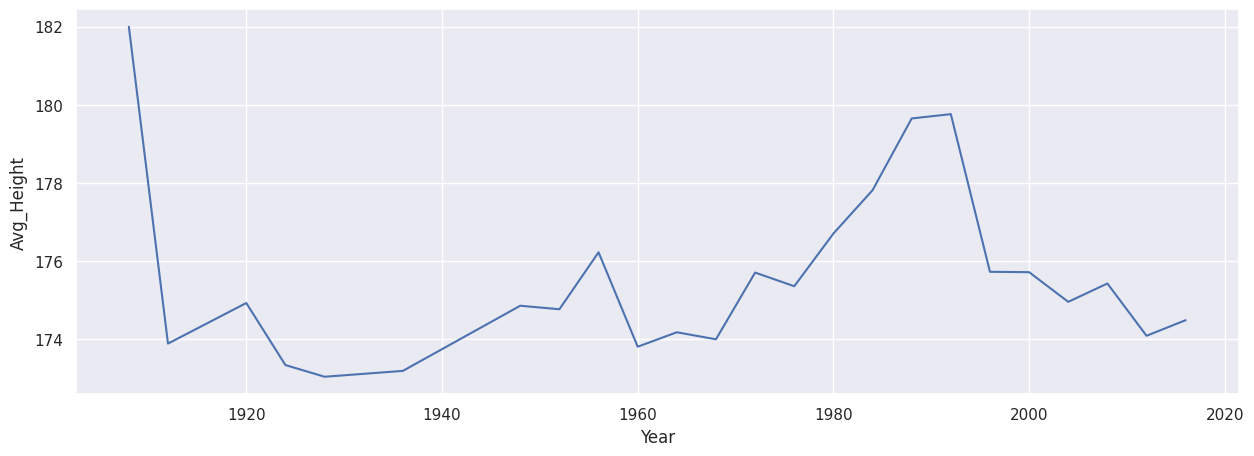

In [27]:
evo_per_year = df[df['Height'] > 0].groupby(['Sport', 'Year'])['Height'].mean().round(2).reset_index(name='Avg_Height').sort_values(['Sport', 'Year'])

def choose_sport(sport: str, df: pd.DataFrame):
    try:
      if sport in df['Sport'].unique():
        return df[df['Sport'] == sport][['Year', 'Avg_Height']].reset_index(drop=True)
    except ValueError:
      raise ValueError(f'Sport {sport} not found')

print(f'Options: {evo_per_year['Sport'].sort_values().unique()}')
sport = input('Insert Sport: ')
sport_df = choose_sport(sport, evo_per_year)

print(sport_df)

fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(data=sport_df, x='Year', y='Avg_Height')

delete_df(evo_per_year)
delete_df(sport_df)

# *5.6 - AVERAGE HEIGHT BY SPORT (MEDALIST)*

              Sport  Avg_Height
0        Basketball      191.99
1        Volleyball      186.90
2  Beach Volleyball      186.82
3        Water Polo      185.24
4            Rowing      184.45
5    Figure Skating      168.51
6     Weightlifting      167.48
7      Trampolining      166.31
8            Diving      165.64
9        Gymnastics      161.58


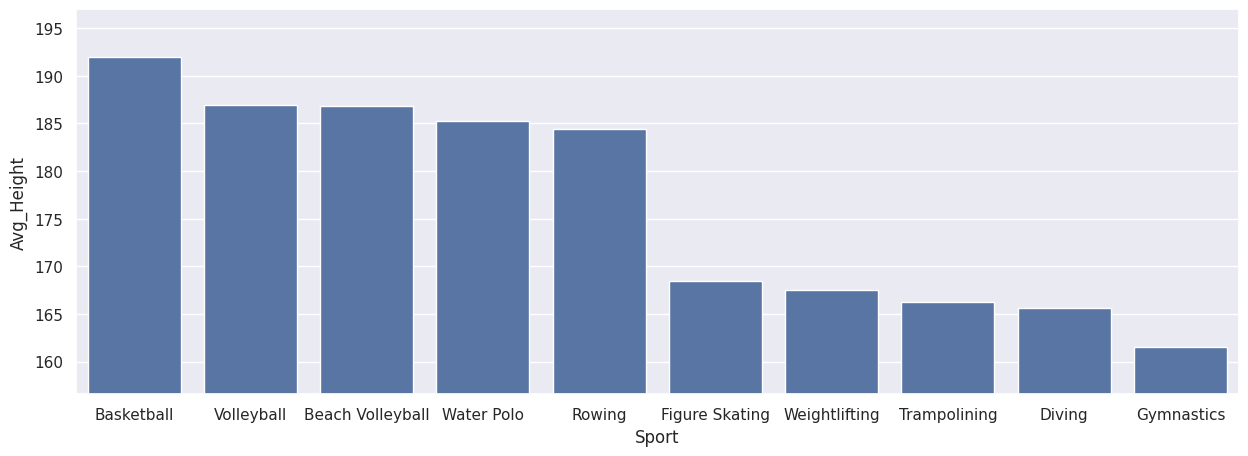

In [28]:
avg_height_medalist = df[df['Medal'].notna() & (df['Height'] > 0)].groupby(['Sport'])['Height'].mean().round(2).reset_index(name='Avg_Height').sort_values('Avg_Height', ascending=False).reset_index(drop=True)

avg_height_medalist_head = avg_height_medalist.head()
avg_height_medalist_tail = avg_height_medalist.tail()

avg_height_medalist = pd.concat([avg_height_medalist_head, avg_height_medalist_tail]).reset_index(drop=True)

print(avg_height_medalist)

fig, ax = plt.subplots(figsize=(15, 5))
sns.barplot(data=avg_height_medalist, x='Sport', y='Avg_Height', ax=ax)

plt.ylim(avg_height_medalist['Avg_Height'].min() - 5.0, avg_height_medalist['Avg_Height'].max() + 5.0)
plt.show()

delete_df(avg_height_medalist)

# **EXTRA SCRIPT - STANDARD DEVIATION**
# *HEIGHT*

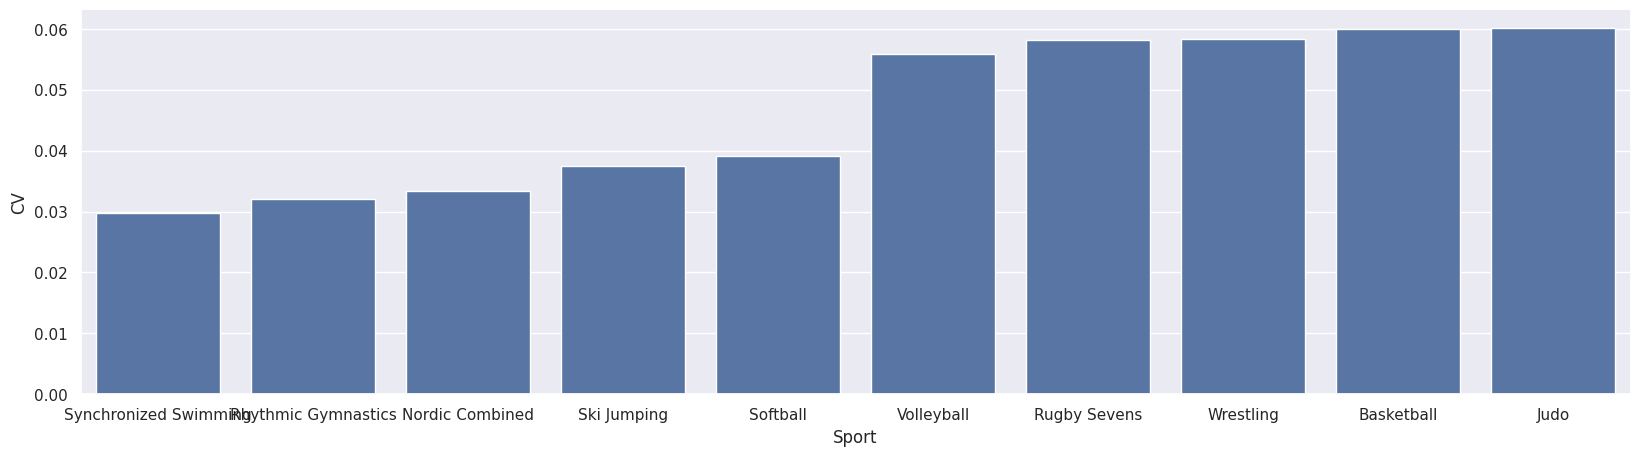

In [31]:
height = (df[df['Height'] > 0]
          .groupby(['Sport'])['Height']
          .agg(
               Avg_Height = 'mean',
               Std_Dev    = 'std',
               Min_Height = 'min',
               Max_Height = 'max',
               Count = 'count',
          )
          .round({
               "Avg_Height": 2,
               "Std_Dev": 2,
          })
          .sort_values('Std_Dev', ascending=False)
          .reset_index()
)

height = height[height['Count'] > 50].dropna()

height['CV'] = np.round(height['Std_Dev'] / height['Avg_Height'], 4).sort_values(ascending=False)

height_tail = height.tail(5)
height_head = height.head(5)

height = pd.concat([height_tail, height_head]).sort_values('CV').reset_index(drop=True)

height

fig, ax = plt.subplots(figsize=(20, 5))
sns.barplot(data=height, x='Sport', y='CV', ax=ax)
plt.show()

delete_df(height)